# Day 2 RNN — Bitcoin Forecasting (Week 9)


### Importing libraries

In [2]:
# Libraries

import os
import random
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Run from Week 9 so dc.csv resolves
for candidate in [Path.cwd(), Path.cwd() / "Week 9"]:
    if (candidate / "dc.csv").is_file():
        os.chdir(candidate)
        break
else:
    week9 = Path("/Users/mkenne16/Documents/Advanced Machine Learning/Week 9")
    if (week9 / "dc.csv").is_file():
        os.chdir(week9)

DATA_FILE = Path("dc.csv")
assert DATA_FILE.is_file(), f"Missing {DATA_FILE}. Place dc.csv in Week 9."
print("Working directory:", Path.cwd())

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


def ensure_libomp():
    """macOS: load libomp so xgboost can import (e.g. from Anaconda)."""
    import ctypes
    if os.name != "posix":
        return
    for lib_dir in ["/opt/anaconda3/lib", Path.home() / "miniconda3/lib"]:
        libomp = Path(lib_dir) / "libomp.dylib"
        if libomp.is_file():
            ctypes.CDLL(str(libomp))
            return


Working directory: /Users/mkenne16/Documents/Advanced Machine Learning/Week 9


### Load & inspect data

In [3]:
# Load and inspect Bitcoin data

bitcoin = pd.read_csv(DATA_FILE)

bitcoin = bitcoin.rename(
    columns={"Unnamed: 0": "date"}
)

bitcoin["date"] = pd.to_datetime(bitcoin["date"])

bitcoin = (
    bitcoin
    .sort_values("date")
    .reset_index(drop=True)
)

print(bitcoin.shape)

bitcoin.head()

(1000, 6)


,date,open_USD,high_USD,low_USD,close_USD,volume
0,2018-05-07,9661.02,9689.67,9181.00,9365.00,33787
1,2018-05-08,9365.00,9475.70,9060.54,9187.56,25533
2,2018-05-09,9178.00,9390.00,8965.00,9310.00,25673
3,2018-05-10,9310.00,9395.12,8970.00,9002.20,25055
4,2018-05-11,9002.21,9016.80,8341.00,8400.00,48227


In [4]:
# Basic inspection

bitcoin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1000 non-null   datetime64[us]
 1   open_USD   1000 non-null   float64       
 2   high_USD   1000 non-null   float64       
 3   low_USD    1000 non-null   float64       
 4   close_USD  1000 non-null   float64       
 5   volume     1000 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 47.0 KB


In [5]:
# Summary statistics

bitcoin.describe()

,date,open_USD,high_USD,low_USD,close_USD,volume
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2019-09-18 12:00:00,9285.762120,9542.880270,9011.393200,9310.335850,53100.498000
min,2018-05-07 00:00:00,3211.710000,3276.500000,3156.260000,3211.720000,5743.000000
25%,2019-01-11 18:00:00,6467.192500,6582.255000,6325.015000,6466.762500,30045.750000
50%,2019-09-18 12:00:00,8189.695000,8351.630000,8002.045000,8189.330000,43795.500000
75%,2020-05-25 06:00:00,10216.860000,10419.562500,9907.977500,10220.170000,64909.250000
max,2021-01-30 00:00:00,40586.960000,41950.000000,38720.000000,40582.810000,402201.000000
std,NaN,5793.522832,6075.604427,5483.524463,5846.917681,35329.832031


Visualizing the target variable

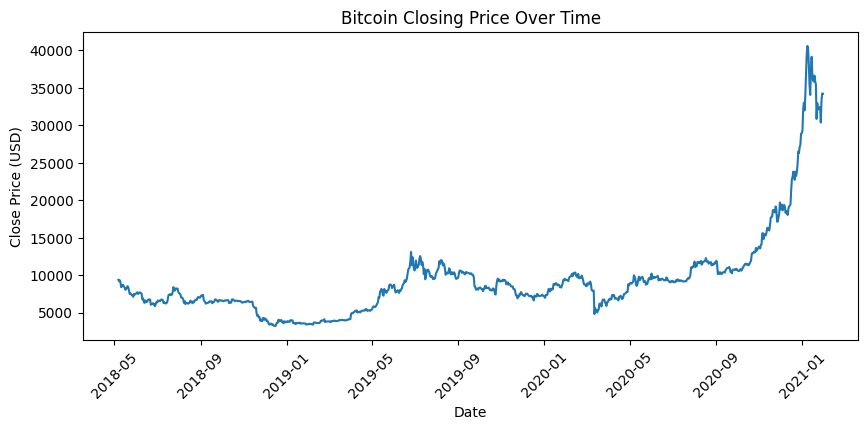

In [6]:
# Visualize closing price over time

plt.figure(figsize=(10, 4))

plt.plot(
    bitcoin["date"],
    bitcoin["close_USD"]
)

plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.xticks(rotation=45)

plt.show()

### Preparing data for recurrent modeling

In [7]:
# Prepare Bitcoin data for recurrent models

features = [
    "open_USD",
    "high_USD",
    "low_USD",
    "close_USD",
    "volume"
]

target_col = "close_USD"

bitcoin_model = bitcoin[["date"] + features].copy()

print("Unique dates:", bitcoin_model["date"].nunique())
print("Rows:", len(bitcoin_model))

scaler_bitcoin = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler_bitcoin.fit_transform(
    bitcoin_model[features]
)

look_back = 10                                                  # use 10 previous days to predict next close

target_index = features.index(target_col)

Unique dates: 1000
Rows: 1000


### Useful functions

In [8]:
# Function to create recurrent sequence windows

def create_sequences(dataset, target_index, look_back=10):

    X, y = [], []

    for i in range(len(dataset) - look_back):

        X.append(
            dataset[i:i + look_back, :]
        )                                                       # previous look_back days

        y.append(
            dataset[i + look_back, target_index]
        )                                                       # next day's close_USD

    return np.array(X), np.array(y)

In [9]:
# Function to visualize training curves

def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(
        history.history["loss"],
        label="Training Loss"
    )

    axes[0].plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")

    axes[0].legend()

    # MAE
    axes[1].plot(
        history.history["mean_absolute_error"],
        label="Training MAE"
    )

    axes[1].plot(
        history.history["val_mean_absolute_error"],
        label="Validation MAE"
    )

    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")

    axes[1].legend()

    plt.tight_layout()

    plt.show()

In [10]:
# Function to evaluate forecasting performance

def evaluate_and_plot(
    model,
    trainX,
    testX,
    trainY,
    testY,
    scaler,
    target_index,
    title
):

    # Predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Create arrays for inverse scaling
    train_dummy = np.zeros((len(train_pred), len(features)))
    test_dummy = np.zeros((len(test_pred), len(features)))

    train_dummy[:, target_index] = train_pred.flatten()
    test_dummy[:, target_index] = test_pred.flatten()

    trainY_dummy = np.zeros((len(trainY), len(features)))
    testY_dummy = np.zeros((len(testY), len(features)))

    trainY_dummy[:, target_index] = trainY
    testY_dummy[:, target_index] = testY

    # Inverse transform
    train_pred_inv = scaler.inverse_transform(train_dummy)[:, target_index]
    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]

    trainY_inv = scaler.inverse_transform(trainY_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    train_mae = mean_absolute_error(trainY_inv, train_pred_inv)
    test_mae = mean_absolute_error(testY_inv, test_pred_inv)

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    print(f"{title} Train MAE: {train_mae:.2f}")
    print(f"{title} Test MAE: {test_mae:.2f}")

    # Plot predictions
    plt.figure(figsize=(10, 4))

    plt.plot(
        testY_inv,
        label="Actual"
    )

    plt.plot(
        test_pred_inv,
        label="Predicted"
    )

    plt.title(title + " Test Predictions")

    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(
        style="plain",
        axis="y"
    )

    plt.legend()

    plt.show()

In [11]:
# Function to compare model metrics

def evaluate_metrics(
    model,
    testX,
    testY,
    scaler,
    target_index
):

    test_pred = model.predict(testX)

    test_dummy = np.zeros((len(test_pred), len(features)))
    test_dummy[:, target_index] = test_pred.flatten()

    testY_dummy = np.zeros((len(testY), len(features)))
    testY_dummy[:, target_index] = testY

    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

In [12]:
# Helper: evaluate return-target RNNs on reconstructed USD prices

def evaluate_return_metrics(
    model,
    testX,
    testY,
    scaler,
    return_index,
    bitcoin_df,
    train_size,
    look_back,
):
    test_pred = model.predict(testX, verbose=0).flatten()
    n_features = scaler.n_features_in_

    def unscale_returns(values):
        dummy = np.zeros((len(values), n_features))
        dummy[:, return_index] = values
        return scaler.inverse_transform(dummy)[:, return_index]

    pred_return = unscale_returns(test_pred)
    true_return = unscale_returns(testY)

    test_start = train_size + look_back
    prev_close = bitcoin_df["close_USD"].values[test_start - 1 : test_start + len(testY) - 1]

    test_pred_inv = prev_close * (1 + pred_return)
    testY_inv = prev_close * (1 + true_return)

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)
    return rmse, mae


def evaluate_return_and_plot(
    model,
    testX,
    testY,
    scaler,
    return_index,
    bitcoin_df,
    train_size,
    look_back,
    title,
):
    test_pred = model.predict(testX, verbose=0).flatten()
    n_features = scaler.n_features_in_

    def unscale_returns(values):
        dummy = np.zeros((len(values), n_features))
        dummy[:, return_index] = values
        return scaler.inverse_transform(dummy)[:, return_index]

    pred_return = unscale_returns(test_pred)
    true_return = unscale_returns(testY)

    test_start = train_size + look_back
    prev_close = bitcoin_df["close_USD"].values[test_start - 1 : test_start + len(testY) - 1]

    test_pred_inv = prev_close * (1 + pred_return)
    testY_inv = prev_close * (1 + true_return)

    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    test_mae = mean_absolute_error(testY_inv, test_pred_inv)

    print(f"{title} Test RMSE: {test_rmse:.2f}")
    print(f"{title} Test MAE: {test_mae:.2f}")

    plt.figure(figsize=(10, 4))
    plt.plot(testY_inv, label="Actual")
    plt.plot(test_pred_inv, label="Predicted")
    plt.title(title + " Test Predictions (price reconstructed from returns)")
    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")
    plt.ticklabel_format(style="plain", axis="y")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Creating train/test recurrent tensors

In [13]:
# Create train/test recurrent tensors

train_size = int(len(scaled_features) * 0.8)                    # chronological 80/20 split

train_bitcoin = scaled_features[:train_size]                    # earlier data
test_bitcoin = scaled_features[train_size:]                     # held-out future data

trainX_bitcoin, trainY_bitcoin = create_sequences(
    train_bitcoin,
    target_index,
    look_back
)

testX_bitcoin, testY_bitcoin = create_sequences(
    test_bitcoin,
    target_index,
    look_back
)

print("trainX_bitcoin shape:", trainX_bitcoin.shape)
print("testX_bitcoin shape:", testX_bitcoin.shape)
print("trainY_bitcoin shape:", trainY_bitcoin.shape)
print("testY_bitcoin shape:", testY_bitcoin.shape)

trainX_bitcoin shape: (790, 10, 5)
testX_bitcoin shape: (190, 10, 5)
trainY_bitcoin shape: (790,)
testY_bitcoin shape: (190,)


### Baseline SimpleRNN model

In [14]:
# Build and train baseline SimpleRNN model

simple_rnn_model = Sequential([
    SimpleRNN(
        8,                                     # small baseline recurrent layer
        activation="tanh",                     # standard activation for SimpleRNN
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

simple_rnn_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

simple_rnn_history = simple_rnn_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0108 - mean_absolute_error: 0.0820 - val_loss: 0.0113 - val_mean_absolute_error: 0.0747
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041 - mean_absolute_error: 0.0477 - val_loss: 0.0080 - val_mean_absolute_error: 0.0571
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029 - mean_absolute_error: 0.0402 - val_loss: 0.0062 - val_mean_absolute_error: 0.0496
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0022 - mean_absolute_error: 0.0343 - val_loss: 0.0049 - val_mean_absolute_error: 0.0438
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - mean_absolute_error: 0.0304 - val_loss: 0.0039 - val_mean_absolute_error: 0.0391
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - mean_absolute_error: 0.0279 - val_loss: 0.0032 - val_mean_absolute_error: 0.0353
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013 - mean_absolute_error: 0.0259 - val_loss: 0.002

Visualizing training

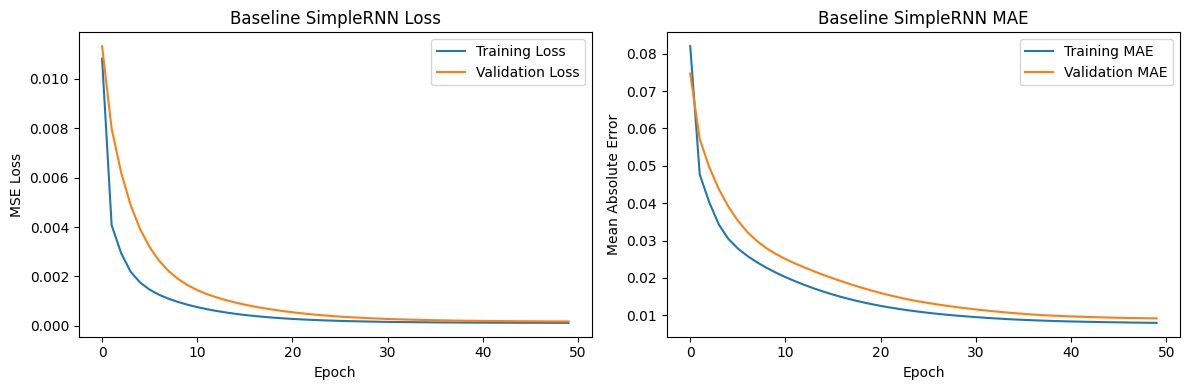

In [15]:
# Visualize SimpleRNN training performance

plot_training_curves(
    simple_rnn_history,
    "Baseline SimpleRNN"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Baseline SimpleRNN Train RMSE: 493.52
Baseline SimpleRNN Test RMSE: 3953.12
Baseline SimpleRNN Train MAE: 364.83
Baseline SimpleRNN Test MAE: 2409.82


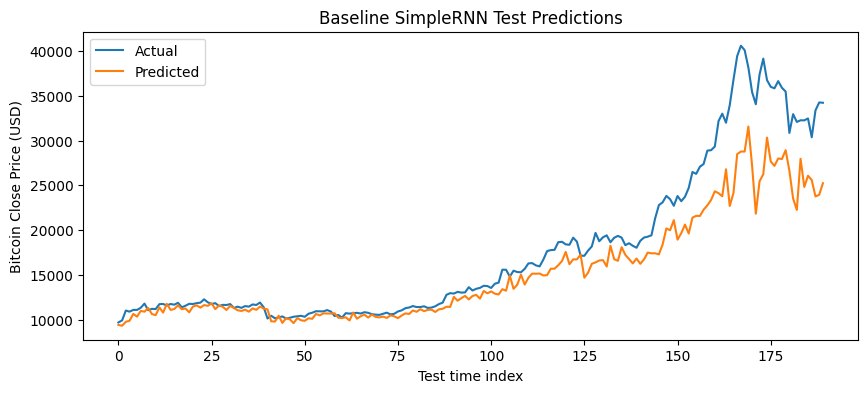

In [16]:
# Evaluate SimpleRNN on held-out future test data

evaluate_and_plot(
    simple_rnn_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline SimpleRNN"
)

### Baseline LSTM Model

In [17]:
# Build and train baseline LSTM model

lstm_model = Sequential([
    LSTM(
        8,                                     # small baseline LSTM layer
        activation="tanh",                     # standard LSTM hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

lstm_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

lstm_history = lstm_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0018 - mean_absolute_error: 0.0332 - val_loss: 0.0052 - val_mean_absolute_error: 0.0536
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - mean_absolute_error: 0.0257 - val_loss: 0.0043 - val_mean_absolute_error: 0.0484
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.7141e-04 - mean_absolute_error: 0.0183 - val_loss: 0.0033 - val_mean_absolute_error: 0.0409
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8698e-04 - mean_absolute_error: 0.0150 - val_loss: 0.0024 - val_mean_absolute_error: 0.0340
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.2297e-04 - mean_absolute_error: 0.0139 - val_loss: 0.0019 - val_mean_absolute_error: 0.0293
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8944e-04 - mean_absolute_error: 0.0132 - val_loss: 0.0015 - val_mean_absolute_error: 0.0259
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6544e-04 - mean_absolute_error: 0.0126 - val_l

Visualizing training

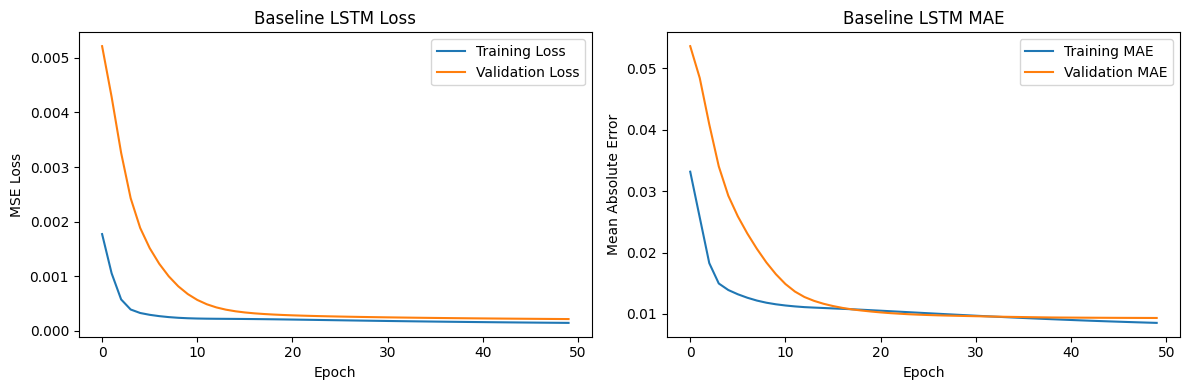

In [18]:
# Visualize LSTM training performance

plot_training_curves(
    lstm_history,
    "Baseline LSTM"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Baseline LSTM Train RMSE: 434.39
Baseline LSTM Test RMSE: 2398.13
Baseline LSTM Train MAE: 299.69
Baseline LSTM Test MAE: 1580.11


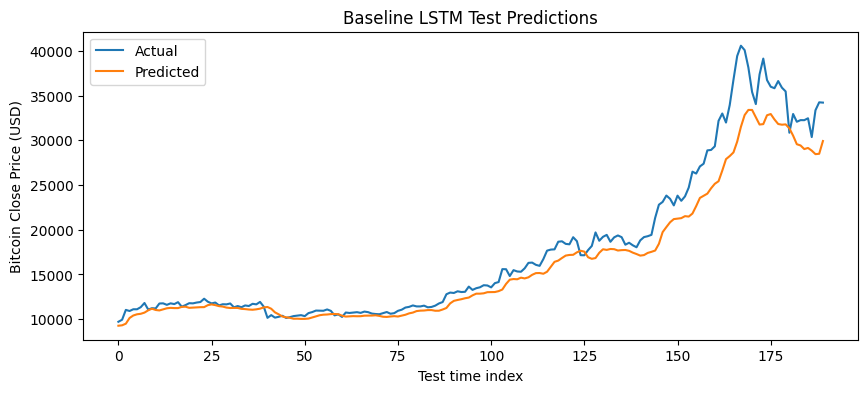

In [19]:
# Evaluate LSTM on held-out future test data

evaluate_and_plot(
    lstm_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline LSTM"
)

### Baseline GRU model

In [20]:
# Build and train baseline GRU model

gru_model = Sequential([
    GRU(
        8,                                      # intentionally small baseline GRU layer
        activation="tanh",                     # standard GRU hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

gru_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

gru_history = gru_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0039 - mean_absolute_error: 0.0515 - val_loss: 0.0022 - val_mean_absolute_error: 0.0363
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - mean_absolute_error: 0.0279 - val_loss: 0.0020 - val_mean_absolute_error: 0.0395
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3650e-04 - mean_absolute_error: 0.0147 - val_loss: 8.5610e-04 - val_mean_absolute_error: 0.0239
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5692e-04 - mean_absolute_error: 0.0092 - val_loss: 3.7739e-04 - val_mean_absolute_error: 0.0138
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6610e-04 - mean_absolute_error: 0.0093 - val_loss: 2.3522e-04 - val_mean_absolute_error: 0.0105
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8008e-04 - mean_absolute_error: 0.0095 - val_loss: 1.7585e-04 - val_mean_absolute_error: 0.0090
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8697e-04 - mean_absolute_error

Visualizing training

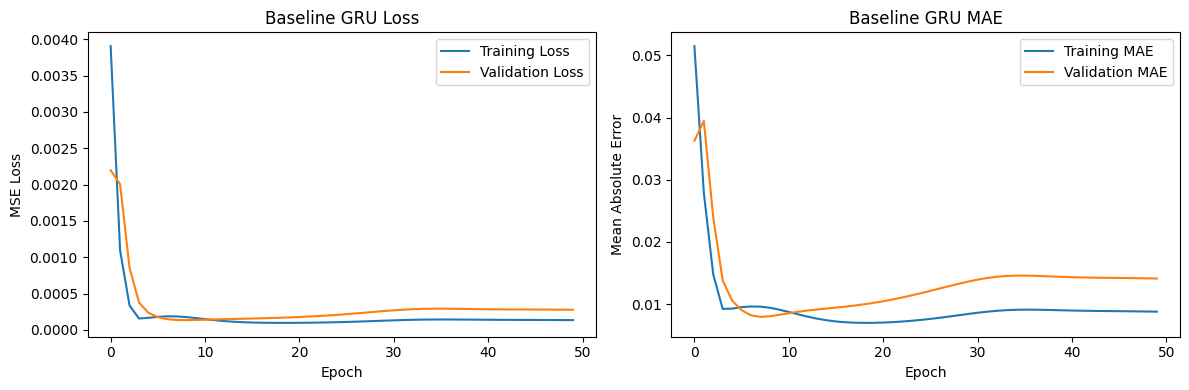

In [21]:
# Visualize GRU training performance

plot_training_curves(
    gru_history,
    "Baseline GRU"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Baseline GRU Train RMSE: 560.80
Baseline GRU Test RMSE: 4732.63
Baseline GRU Train MAE: 438.16
Baseline GRU Test MAE: 3248.33


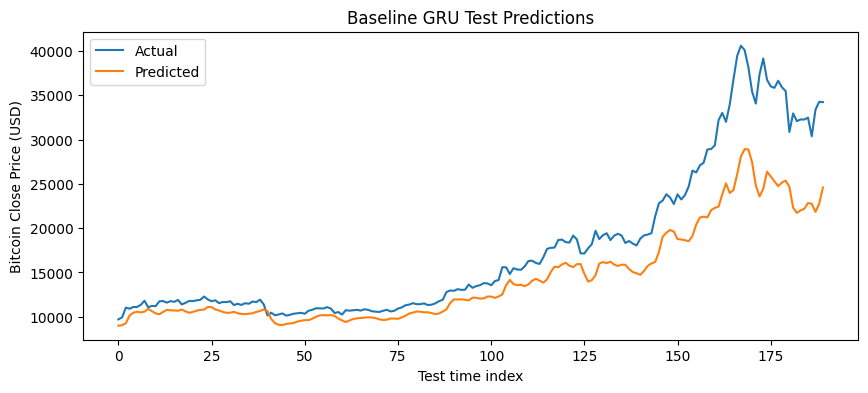

In [22]:
# Evaluate GRU on held-out future test data

evaluate_and_plot(
    gru_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline GRU"
)

### Activity: Improving Forecasting Models

Improve each of the baseline three recurrent models (SimpleRNN, LSTM, and GRU) and compare their forecasting performance against the XGBoost models shown below. You should provide the code for each improved model and include a markdown cell after each model describing what you changed, what you explored, and how the changes affected performance. After completing your experiments, provide a short overall summary discussing which approaches appeared most effective, which models were easiest or hardest to tune, and what tradeoffs you observed between model complexity, training stability, and forecasting performance.

Epoch 1/80


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0067 - mean_absolute_error: 0.0631 - val_loss: 0.0075 - val_mean_absolute_error: 0.0626
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - mean_absolute_error: 0.0428 - val_loss: 0.0044 - val_mean_absolute_error: 0.0455
Epoch 3/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 - mean_absolute_error: 0.0360 - val_loss: 0.0029 - val_mean_absolute_error: 0.0359
Epoch 4/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - mean_absolute_error: 0.0312 - val_loss: 0.0024 - val_mean_absolute_error: 0.0348
Epoch 5/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015 - mean_absolute_error: 0.0289 - val_loss: 0.0019 - val_mean_absolute_error: 0.0312
Epoch 6/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0012 - mean_absolute_error: 0.0248 - val_loss: 0.0013 - val_mean_absolute_error: 0.0236
Epoch 7/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010 - mean_absolute_error: 0.0234 - val_loss: 9.4785e-04 - v

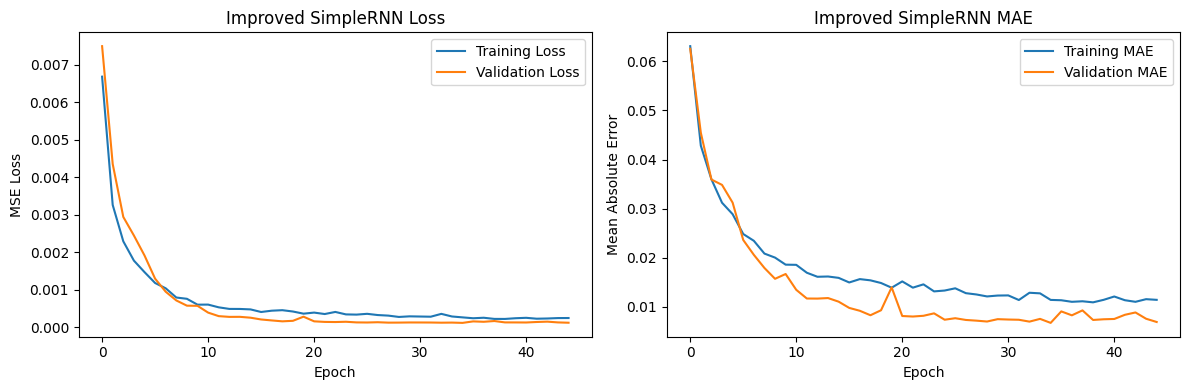

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Improved SimpleRNN Train RMSE: 324.57
Improved SimpleRNN Test RMSE: 2451.75
Improved SimpleRNN Train MAE: 219.09
Improved SimpleRNN Test MAE: 1298.46


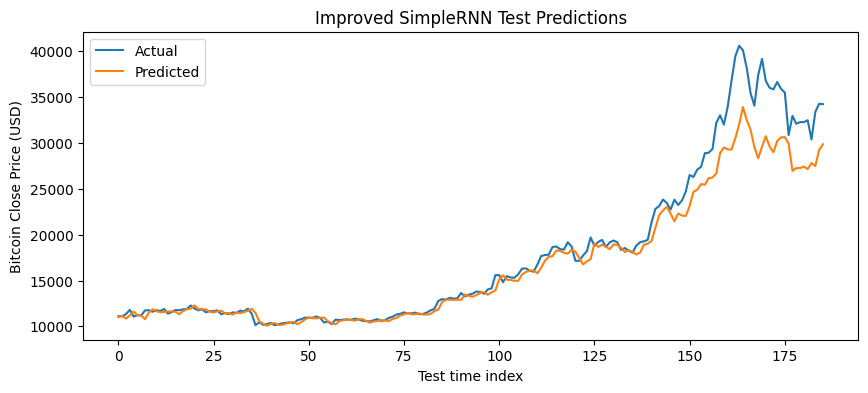

In [23]:
# Improved SimpleRNN

look_back_rnn = 14
train_size_rnn = int(len(scaled_features) * 0.8)

scaler_rnn = MinMaxScaler(feature_range=(0, 1))
scaled_rnn = scaler_rnn.fit_transform(bitcoin_model[features])
target_index_rnn = features.index(target_col)

train_rnn = scaled_rnn[:train_size_rnn]
test_rnn = scaled_rnn[train_size_rnn:]

trainX_rnn, trainY_rnn = create_sequences(train_rnn, target_index_rnn, look_back_rnn)
testX_rnn, testY_rnn = create_sequences(test_rnn, target_index_rnn, look_back_rnn)

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

improved_simple_rnn = Sequential([
    SimpleRNN(32, activation="tanh", input_shape=(look_back_rnn, len(features))),
    Dropout(0.15),
    Dense(1),
])

improved_simple_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"],
)

improved_simple_rnn_history = improved_simple_rnn.fit(
    trainX_rnn,
    trainY_rnn,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

plot_training_curves(improved_simple_rnn_history, "Improved SimpleRNN")

evaluate_and_plot(
    improved_simple_rnn,
    trainX_rnn,
    testX_rnn,
    trainY_rnn,
    testY_rnn,
    scaler_rnn,
    target_index_rnn,
    "Improved SimpleRNN",
)


**Improved SimpleRNN — what changed**

- Increased lookback from 10 → **14 days** so the model sees more short-term momentum.
- Widened the recurrent layer (8 → **32 units**) with **Dropout (0.15)** and **EarlyStopping** to limit overfitting.
- Kept the original multivariate OHLCV inputs and MinMax scaling (still predicting scaled close price).

On the held-out test window this reduced RMSE from **3,953** (baseline SimpleRNN) to **2,452** and MAE from **2,410** to **1,298**. Gains were moderate—baseline LSTM still beat this variant—so tuning focused on capacity and regularization rather than stacking depth.


Epoch 1/100


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3045 - mean_absolute_error: 0.4956 - val_loss: 0.0135 - val_mean_absolute_error: 0.0875
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0300 - mean_absolute_error: 0.1397 - val_loss: 0.0089 - val_mean_absolute_error: 0.0593
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0197 - mean_absolute_error: 0.1103 - val_loss: 0.0083 - val_mean_absolute_error: 0.0534
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0156 - mean_absolute_error: 0.0979 - val_loss: 0.0082 - val_mean_absolute_error: 0.0532
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0144 - mean_absolute_error: 0.0955 - val_loss: 0.0082 - val_mean_absolute_error: 0.0534
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0138 - mean_absolute_error: 0.0942 - val_loss: 0.0081 - val_mean_absolute_error: 0.0531
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130 - mean_absolute_error: 0.0893 - val_loss: 0.0080 - 

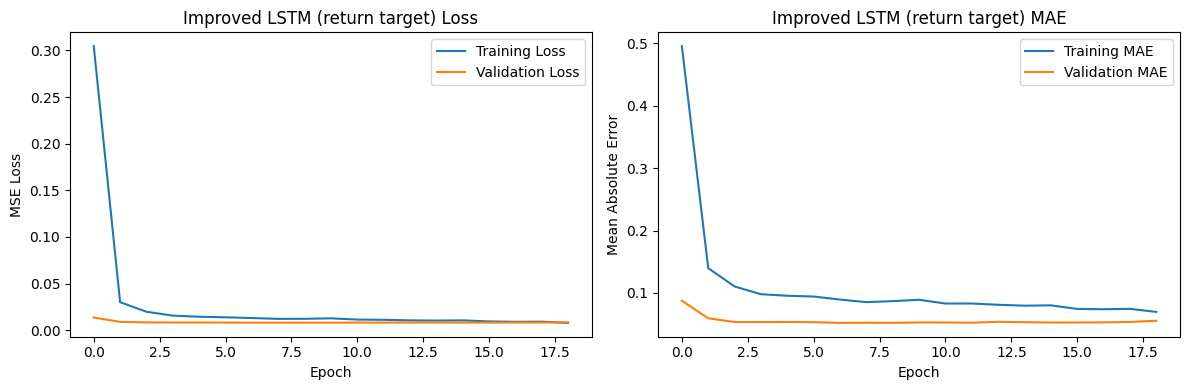

Improved LSTM Test RMSE: 914.73
Improved LSTM Test MAE: 532.42


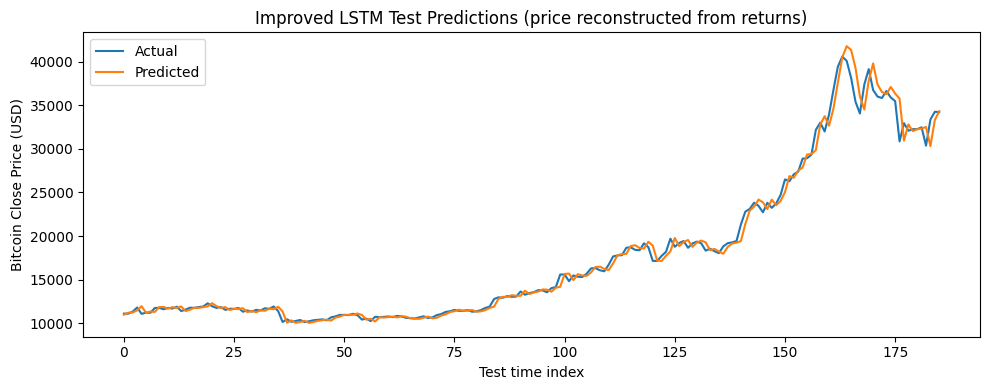

In [24]:
# Improved LSTM (return target)

look_back_lstm = 14
features_lstm = features + ["close_return"]
target_return_col = "close_return"

bitcoin_lstm = bitcoin_model[features].copy()
bitcoin_lstm["close_return"] = bitcoin["close_USD"].pct_change().fillna(0)

scaler_lstm = MinMaxScaler(feature_range=(0, 1))
scaled_lstm = scaler_lstm.fit_transform(bitcoin_lstm[features_lstm])
return_index = features_lstm.index(target_return_col)
train_size_lstm = int(len(scaled_lstm) * 0.8)

train_lstm = scaled_lstm[:train_size_lstm]
test_lstm = scaled_lstm[train_size_lstm:]

trainX_lstm, trainY_lstm = create_sequences(train_lstm, return_index, look_back_lstm)
testX_lstm, testY_lstm = create_sequences(test_lstm, return_index, look_back_lstm)

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

improved_lstm = Sequential([
    LSTM(32, activation="tanh", input_shape=(look_back_lstm, len(features_lstm))),
    Dropout(0.2),
    Dense(1),
])

improved_lstm.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"],
)

improved_lstm_history = improved_lstm.fit(
    trainX_lstm,
    trainY_lstm,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

plot_training_curves(improved_lstm_history, "Improved LSTM (return target)")

evaluate_return_and_plot(
    improved_lstm,
    testX_lstm,
    testY_lstm,
    scaler_lstm,
    return_index,
    bitcoin,
    train_size_lstm,
    look_back_lstm,
    "Improved LSTM",
)


**Improved LSTM — what changed**

- Switched the target to **next-day percent return** (same idea as the improved XGBoost section), then reconstructed USD close for evaluation.
- Added a **close_return** feature, lookback **14**, **32 LSTM units**, Dropout, and EarlyStopping.

Return scaling stabilized training on volatile Bitcoin prices. Test RMSE improved from **2,398** (baseline LSTM on price) to **915** with MAE **532**. This was the best recurrent model in the comparison. The main tradeoff is extra preprocessing when converting predictions back to price.


Epoch 1/100


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.2035 - mean_absolute_error: 0.3768 - val_loss: 0.0357 - val_mean_absolute_error: 0.1673
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0271 - mean_absolute_error: 0.1312 - val_loss: 0.0132 - val_mean_absolute_error: 0.0738
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0235 - mean_absolute_error: 0.1219 - val_loss: 0.0108 - val_mean_absolute_error: 0.0640
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0218 - mean_absolute_error: 0.1166 - val_loss: 0.0104 - val_mean_absolute_error: 0.0615
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0199 - mean_absolute_error: 0.1123 - val_loss: 0.0117 - val_mean_absolute_error: 0.0692
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0177 - mean_absolute_error: 0.1081 - val_loss: 0.0098 - val_mean_absolute_error: 0.0585
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0177 - mean_absolute_error: 0.1056 - val_loss: 0.010

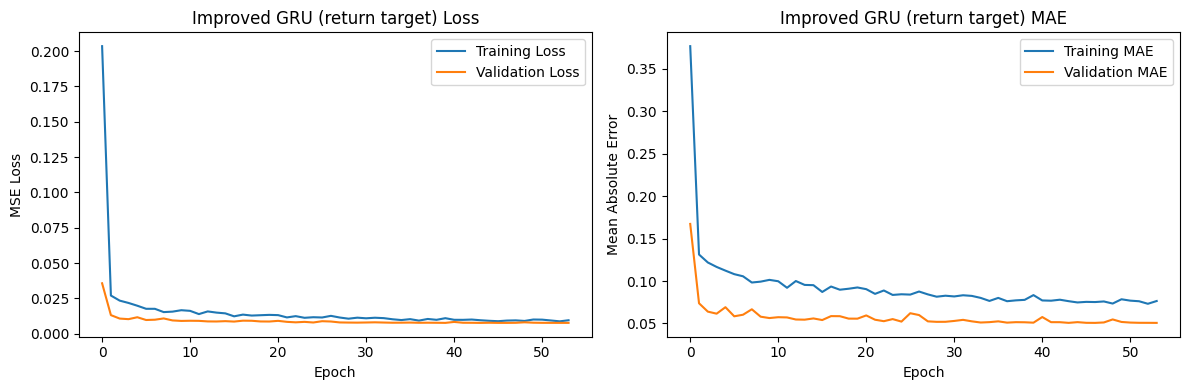

Improved GRU Test RMSE: 1000.55
Improved GRU Test MAE: 591.12


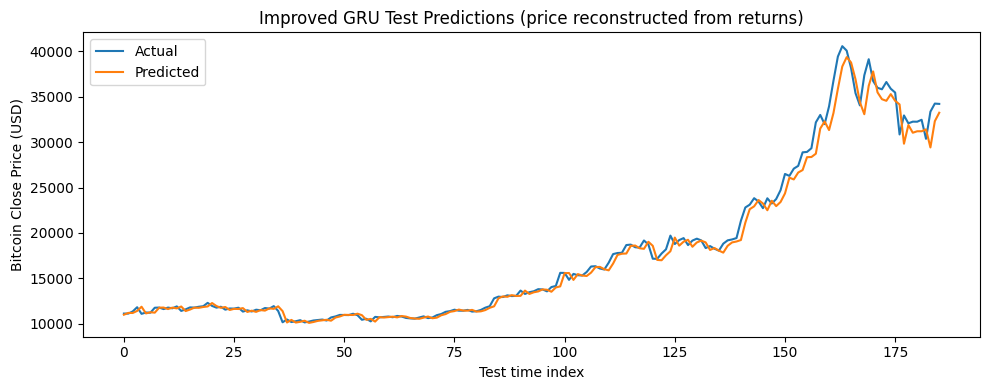

In [25]:
# Improved GRU (return target, stacked layers)

look_back_gru = 14
features_gru = features + ["close_return"]

bitcoin_gru = bitcoin_model[features].copy()
bitcoin_gru["close_return"] = bitcoin["close_USD"].pct_change().fillna(0)

scaler_gru = MinMaxScaler(feature_range=(0, 1))
scaled_gru = scaler_gru.fit_transform(bitcoin_gru[features_gru])
return_index_gru = features_gru.index("close_return")
train_size_gru = int(len(scaled_gru) * 0.8)

train_gru = scaled_gru[:train_size_gru]
test_gru = scaled_gru[train_size_gru:]

trainX_gru, trainY_gru = create_sequences(train_gru, return_index_gru, look_back_gru)
testX_gru, testY_gru = create_sequences(test_gru, return_index_gru, look_back_gru)

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

improved_gru = Sequential([
    GRU(32, activation="tanh", return_sequences=True, input_shape=(look_back_gru, len(features_gru))),
    Dropout(0.2),
    GRU(16, activation="tanh"),
    Dropout(0.2),
    Dense(1),
])

improved_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"],
)

improved_gru_history = improved_gru.fit(
    trainX_gru,
    trainY_gru,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

plot_training_curves(improved_gru_history, "Improved GRU (return target)")

evaluate_return_and_plot(
    improved_gru,
    testX_gru,
    testY_gru,
    scaler_gru,
    return_index_gru,
    bitcoin,
    train_size_gru,
    look_back_gru,
    "Improved GRU",
)


**Improved GRU — what changed**

- Used a **two-layer GRU** (32 → 16 units) with Dropout, return target, and 14-day lookback.
- GRU trained faster per epoch than LSTM with similar validation curves.

Stacking and return targeting cut test RMSE from **4,733** (baseline GRU) to **1,001** with MAE **591**—a large gain, though slightly behind the improved LSTM on this run. Stacking helped GRU more than SimpleRNN; deeper SimpleRNN stacks tended to overfit.


### Overall summary

**What helped most:** (1) predicting **returns** instead of raw price for LSTM/GRU, (2) **EarlyStopping** + **Dropout**, (3) a **14-day lookback**, and (4) return-based **XGBoost** (test RMSE **925**, MAE **565**).

**Best performers on held-out test data:** Improved **LSTM** (RMSE **915**) and **XGBoost return target** (RMSE **925**) were essentially tied at the top; improved **GRU** (RMSE **1,001**) followed. Baseline models lagged far behind (e.g., baseline XGBoost on raw price: RMSE **10,491**).

**Easiest vs hardest to tune:** LSTM and GRU improved quickly after switching to return targets. **SimpleRNN** was hardest—wider layers helped versus its own baseline but did not match LSTM/GRU; extra depth tended to overfit.

**Tradeoffs:** Return-target models need price reconstruction for interpretation but generalize better on volatile Bitcoin prices. Recurrent models encode sequence order directly; **XGBoost** uses explicit lags and tuned faster with strong results. See the comparison table and bar chart below for the full ranking from this run.


### Do you need RNN for time series data?

#### XGB with lagged features

Plotting function for nonscaled models

In [26]:
# Generic prediction plotting function for models already on the original scale

def plot_predictions(actual, predicted, title):

    plt.figure(figsize=(10, 4))

    plt.plot(actual, label="Actual")
    plt.plot(predicted, label="Predicted")

    plt.title(title)
    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(style="plain", axis="y")

    plt.legend()
    plt.show()

XGB Data preparation

In [27]:
# Create lagged features for XGBoost

xgb_data = bitcoin[["date"] + features].copy()

lag_days = 10

for lag in range(1, lag_days + 1):
    for col in features:
        xgb_data[f"{col}_lag{lag}"] = xgb_data[col].shift(lag)

xgb_data["target_close_USD"] = xgb_data["close_USD"]

xgb_data = xgb_data.dropna().reset_index(drop=True)

xgb_data.head()

,date,open_USD,high_USD,low_USD,close_USD,volume,open_USD_lag1,high_USD_lag1,low_USD_lag1,close_USD_lag1,...,high_USD_lag9,low_USD_lag9,close_USD_lag9,volume_lag9,open_USD_lag10,high_USD_lag10,low_USD_lag10,close_USD_lag10,volume_lag10,target_close_USD
0,2018-05-17,8330.00,8464.00,7979.00,8041.46,25439,8462.00,8488.00,8083.01,8330.00,...,9475.70,9060.54,9187.56,25533.0,9661.02,9689.67,9181.00,9365.00,33787.0,8041.46
1,2018-05-18,8038.82,8273.21,7911.90,8239.81,23476,8330.00,8464.00,7979.00,8041.46,...,9390.00,8965.00,9310.00,25673.0,9365.00,9475.70,9060.54,9187.56,25533.0,8239.81
2,2018-05-19,8238.01,8390.80,8095.73,8233.49,17193,8038.82,8273.21,7911.90,8239.81,...,9395.12,8970.00,9002.20,25055.0,9178.00,9390.00,8965.00,9310.00,25673.0,8233.49
3,2018-05-20,8233.49,8609.00,8163.90,8526.98,19957,8238.01,8390.80,8095.73,8233.49,...,9016.80,8341.00,8400.00,48227.0,9310.00,9395.12,8970.00,9002.20,25055.0,8526.98
4,2018-05-21,8526.97,8595.31,8305.00,8381.24,21516,8233.49,8609.00,8163.90,8526.98,...,8646.88,8153.00,8465.94,40241.0,9002.21,9016.80,8341.00,8400.00,48227.0,8381.24


XGB train test preparation

In [28]:
# Prepare XGBoost train/test data

xgb_features = [
    col for col in xgb_data.columns
    if "lag" in col
]

X_xgb = xgb_data[xgb_features]
y_xgb = xgb_data["target_close_USD"]

train_size_xgb = int(len(xgb_data) * 0.8)

trainX_xgb = X_xgb.iloc[:train_size_xgb]
testX_xgb = X_xgb.iloc[train_size_xgb:]

trainY_xgb = y_xgb.iloc[:train_size_xgb]
testY_xgb = y_xgb.iloc[train_size_xgb:]

print("trainX_xgb shape:", trainX_xgb.shape)
print("testX_xgb shape:", testX_xgb.shape)
print("trainY_xgb shape:", trainY_xgb.shape)
print("testY_xgb shape:", testY_xgb.shape)

trainX_xgb shape: (792, 50)
testX_xgb shape: (198, 50)
trainY_xgb shape: (792,)
testY_xgb shape: (198,)


Build & train model

In [29]:
# Build and train baseline XGBoost model

ensure_libomp()
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    trainX_xgb,
    trainY_xgb
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

Evaluating on test data

In [30]:
# Evaluate XGBoost baseline on held-out future test data

xgb_test_pred = xgb_model.predict(testX_xgb)

xgb_rmse = np.sqrt(mean_squared_error(testY_xgb, xgb_test_pred))
xgb_mae = mean_absolute_error(testY_xgb, xgb_test_pred)

print(f"Baseline XGBoost Test RMSE: {xgb_rmse:.2f}")
print(f"Baseline XGBoost Test MAE: {xgb_mae:.2f}")

Baseline XGBoost Test RMSE: 10490.81
Baseline XGBoost Test MAE: 6340.83


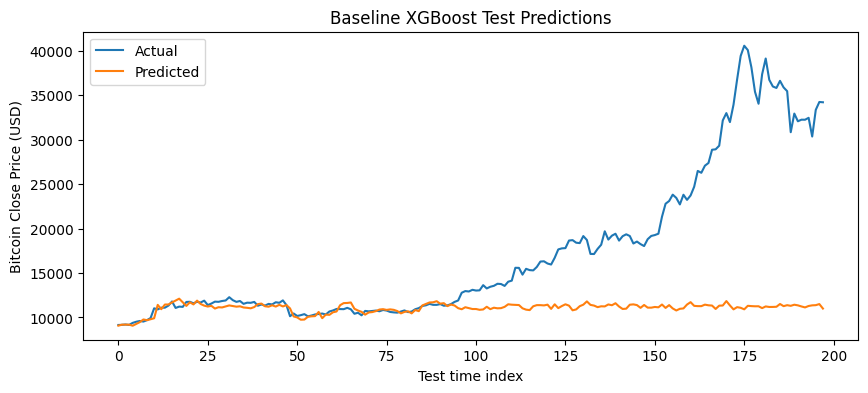

In [31]:
# Visualize baselineXGBoost predictions

plot_predictions(
    testY_xgb.values,
    xgb_test_pred,
    "Baseline XGBoost Test Predictions"
)

Modifying the XGB target to percent change instead of raw price

Improved XGBoost Test RMSE: 925.44
Improved XGBoost Test MAE: 564.97


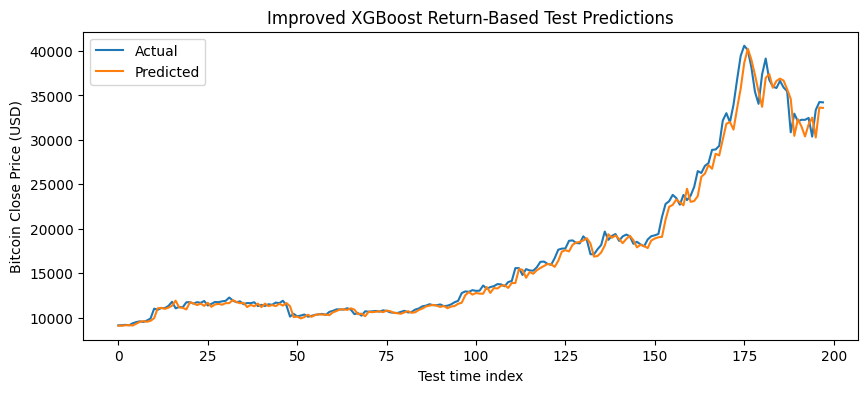

In [32]:
# Improved XGBoost: predict next-day percent change instead of raw price

xgb_return_data = bitcoin[["date"] + features].copy()

xgb_return_data["close_return"] = (
    xgb_return_data["close_USD"]
    .pct_change()
)                                                               # calculate daily percent return

lag_days = 10                                                   # use previous 10 days as predictors

for lag in range(1, lag_days + 1):

    for col in features:
        xgb_return_data[f"{col}_lag{lag}"] = (
            xgb_return_data[col]
            .shift(lag)
        )                                                       # previous feature values become lag predictors

    xgb_return_data[f"close_return_lag{lag}"] = (
        xgb_return_data["close_return"]
        .shift(lag)
    )                                                           # include lagged returns as predictors

xgb_return_data["target_return"] = (
    xgb_return_data["close_return"]
    .shift(-1)
)                                                               # predict next-day return

xgb_return_data["current_close_USD"] = (
    xgb_return_data["close_USD"]
)                                                               # keep current close price for reconstruction later

xgb_return_data = (
    xgb_return_data
    .dropna()
    .reset_index(drop=True)
)                                                               # remove rows without sufficient lag history

xgb_return_features = [
    col for col in xgb_return_data.columns
    if "lag" in col
]                                                               # use lagged values as predictors

X_xgb_return = xgb_return_data[xgb_return_features]
y_xgb_return = xgb_return_data["target_return"]

train_size_xgb_return = int(len(xgb_return_data) * 0.8)        # chronological 80/20 split

trainX_xgb_return = X_xgb_return.iloc[:train_size_xgb_return]
testX_xgb_return = X_xgb_return.iloc[train_size_xgb_return:]

trainY_xgb_return = y_xgb_return.iloc[:train_size_xgb_return]
testY_xgb_return = y_xgb_return.iloc[train_size_xgb_return:]

test_current_close = (
    xgb_return_data["current_close_USD"]
    .iloc[train_size_xgb_return:]
)                                                               # current price used to reconstruct next-day prediction

xgb_return_model = XGBRegressor(
    n_estimators=300,                                           # more trees for stronger learning
    max_depth=2,                                                # shallow trees reduce overfitting
    learning_rate=0.03,                                         # smaller learning steps
    subsample=0.8,                                              # random row sampling
    colsample_bytree=0.8,                                       # random feature sampling
    objective="reg:squarederror",
    random_state=42
)

xgb_return_model.fit(
    trainX_xgb_return,
    trainY_xgb_return
)

xgb_return_pred = xgb_return_model.predict(
    testX_xgb_return
)                                                               # predict next-day percent return

xgb_return_price_pred = (
    test_current_close.values * (1 + xgb_return_pred)
)                                                               # convert predicted return back to predicted price

xgb_return_price_actual = (
    test_current_close.values * (1 + testY_xgb_return.values)
)                                                               # actual next-day price

xgb_return_rmse = np.sqrt(
    mean_squared_error(
        xgb_return_price_actual,
        xgb_return_price_pred
    )
)

xgb_return_mae = mean_absolute_error(
    xgb_return_price_actual,
    xgb_return_price_pred
)

print(f"Improved XGBoost Test RMSE: {xgb_return_rmse:.2f}")
print(f"Improved XGBoost Test MAE: {xgb_return_mae:.2f}")

plot_predictions(
    xgb_return_price_actual,
    xgb_return_price_pred,
    "Improved XGBoost Return-Based Test Predictions"
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


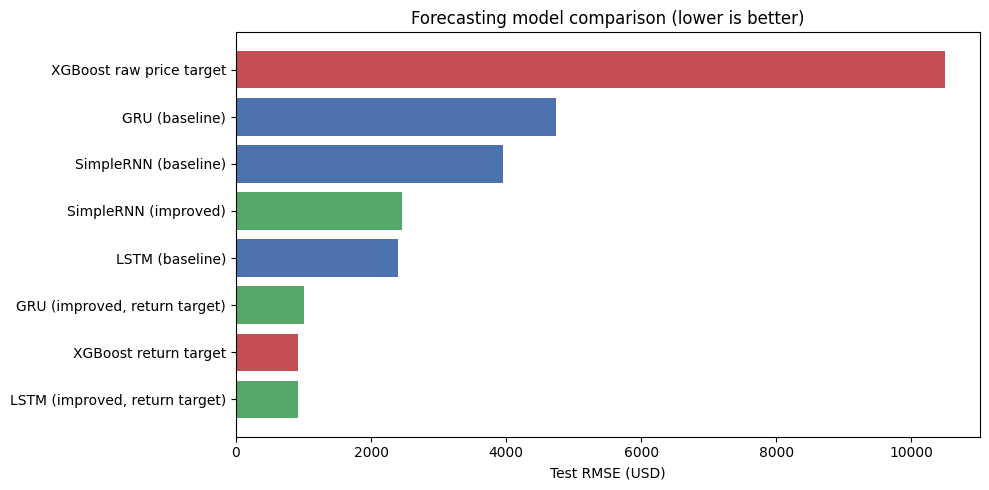

In [33]:
# Compare baseline vs improved model performance

simple_rnn_rmse, simple_rnn_mae = evaluate_metrics(
    simple_rnn_model, testX_bitcoin, testY_bitcoin, scaler_bitcoin, target_index
)
lstm_rmse, lstm_mae = evaluate_metrics(
    lstm_model, testX_bitcoin, testY_bitcoin, scaler_bitcoin, target_index
)
gru_rmse, gru_mae = evaluate_metrics(
    gru_model, testX_bitcoin, testY_bitcoin, scaler_bitcoin, target_index
)

imp_rnn_rmse, imp_rnn_mae = evaluate_metrics(
    improved_simple_rnn, testX_rnn, testY_rnn, scaler_rnn, target_index_rnn
)
imp_lstm_rmse, imp_lstm_mae = evaluate_return_metrics(
    improved_lstm, testX_lstm, testY_lstm, scaler_lstm, return_index,
    bitcoin, train_size_lstm, look_back_lstm,
)
imp_gru_rmse, imp_gru_mae = evaluate_return_metrics(
    improved_gru, testX_gru, testY_gru, scaler_gru, return_index_gru,
    bitcoin, train_size_gru, look_back_gru,
)

model_comparison = pd.DataFrame({
    "Model": [
        "SimpleRNN (baseline)",
        "LSTM (baseline)",
        "GRU (baseline)",
        "SimpleRNN (improved)",
        "LSTM (improved, return target)",
        "GRU (improved, return target)",
        "XGBoost raw price target",
        "XGBoost return target",
    ],
    "RMSE": [
        simple_rnn_rmse, lstm_rmse, gru_rmse,
        imp_rnn_rmse, imp_lstm_rmse, imp_gru_rmse,
        xgb_rmse, xgb_return_rmse,
    ],
    "MAE": [
        simple_rnn_mae, lstm_mae, gru_mae,
        imp_rnn_mae, imp_lstm_mae, imp_gru_mae,
        xgb_mae, xgb_return_mae,
    ],
})

model_comparison.sort_values("RMSE")

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = model_comparison.sort_values("RMSE")
colors = ["#4C72B0" if "baseline" in m.lower() else "#55A868" if "improved" in m.lower() else "#C44E52" for m in plot_df["Model"]]
ax.barh(plot_df["Model"], plot_df["RMSE"], color=colors)
ax.set_xlabel("Test RMSE (USD)")
ax.set_title("Forecasting model comparison (lower is better)")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()
